In [1]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

In [20]:
results = pd.read_csv('../results/lsvt.csv').iloc[:, 1:]
df = results

In [58]:
def get_oracle_mean_std(results: pd.DataFrame):
    oracle_mean = df[df['Approach'] == 'Oracle']['Accuracy'].mean()
    oracle_std = df[df['Approach'] == 'Oracle']['Accuracy'].std()
    return oracle_mean, oracle_std

def preprocess_results(df: pd.DataFrame):
    model_rename = {
        'LogisticRegression': 'LR',
        'RandomForestClassifier': 'RFC',
        'XGBClassifier': 'XGB',
        'SVC' : 'SVC'
    }
    df_copy = df.copy()
    df_copy['base_estimator'] = df_copy['base_estimator'].map(model_rename)

    df_copy['estimator'] = df_copy['base_estimator'] + '_' + df_copy['k_best'].astype(str)
    df_copy['Approach_enriched'] = np.where(
        df_copy['Approach'] == 'self_training',
        'ST_' + df_copy['estimator'],
        df_copy['Approach']
    )
    df_copy = df_copy.drop(columns=['Approach'])
    df_copy = df_copy.rename(columns={'Approach_enriched': 'Approach'})

    return df_copy


def mcar_boxplot(df: pd.DataFrame, metric: str, dataset_name: str):
    oracle_mean, oracle_std = get_oracle_mean_std(df)

    df_copy = preprocess_results(df)

    df_copy = df_copy.loc[lambda df: df['Scheme'].str.startswith('MCAR')]

    plt.figure(figsize=(12, 6))
    sns.boxplot(df_copy, x='Scheme', y='Balanced_Acc', hue='Approach',
                hue_order=['naive', 'label_propagation', 'ST_LR_1.0', 'ST_RFC_1.0', 'ST_XGB_1.0', 'ST_SVC_1.0'], gap=0.1)
    plt.axhline(y=oracle_mean, linestyle='--', color='black', alpha=.6, linewidth=2)

    plt.title(f'{dataset_name} - {metric}')

def mar1_boxplot(df: pd.DataFrame, metric: str, dataset_name: str):
    oracle_mean, oracle_std = get_oracle_mean_std(df)

    df_copy = preprocess_results(df)

    df_copy = df_copy.loc[lambda df: df['Scheme'].str.startswith('MAR1')] 
    df_copy['Scheme'] = 'MAR1'

    df_copy['Scheme_label'] = df_copy['Scheme'] + '\nw=' + df_copy['w1'].astype(str) + ' b=' + df_copy['b1'].astype(str)

    plt.figure(figsize=(12, 6))
    sns.boxplot(df_copy, x='Scheme_label', y='Balanced_Acc', hue='Approach',
                hue_order=['naive', 'label_propagation', 'ST_LR_1.0', 'ST_RFC_1.0', 'ST_XGB_1.0', 'ST_SVC_1.0'], gap=0.1)
    plt.axhline(y=oracle_mean, linestyle='--', color='black', alpha=.6, linewidth=2)

    plt.title(f'{dataset_name} - {metric}')

def mar2_boxplot(df: pd.DataFrame, metric: str, dataset_name: str):
    oracle_mean, oracle_std = get_oracle_mean_std(df)

    df_copy = preprocess_results(df)
    df_copy = df_copy.loc[lambda df: df['Scheme'].str.startswith('MAR2')] 
    df_copy['Scheme'] = 'MAR2'

    df_copy['Scheme_label'] = df_copy['Scheme'] + '\nb=' + df_copy['b2'].astype(str)
    plt.figure(figsize=(12, 6))
    sns.boxplot(df_copy, x='Scheme_label', y='Balanced_Acc', hue='Approach',
                hue_order=['naive', 'label_propagation', 'ST_LR_1.0', 'ST_RFC_1.0', 'ST_XGB_1.0', 'ST_SVC_1.0'], gap=0.1)
    plt.axhline(y=oracle_mean, linestyle='--', color='black', alpha=.6, linewidth=2)

    plt.title(f'{dataset_name} - {metric}')

def mnar_boxplot(df: pd.DataFrame, metric: str, dataset_name: str):
    oracle_mean, oracle_std = get_oracle_mean_std(df)


    df_copy = preprocess_results(df)
    df_copy = df_copy[df_copy['Scheme'].str.startswith('MNAR')]
    df_copy['Scheme'] = 'MNAR' 

    df_copy['Scheme_label'] = df_copy['Scheme'] + '\nwy=' + df_copy['wy'].astype(str) + '_by=' + df_copy['by'].astype(str)
    plt.figure(figsize=(12, 6))

    sns.boxplot(df_copy, x='Scheme_label', y='Balanced_Acc', hue='Approach',
                hue_order=['naive', 'label_propagation', 'ST_LR_1.0', 'ST_RFC_1.0', 'ST_XGB_1.0', 'ST_SVC_1.0'], gap=0.1)
    plt.axhline(y=oracle_mean, linestyle='--', color='black', alpha=.6, linewidth=2)

    plt.title(f'{dataset_name} - {metric}')

### MCAR

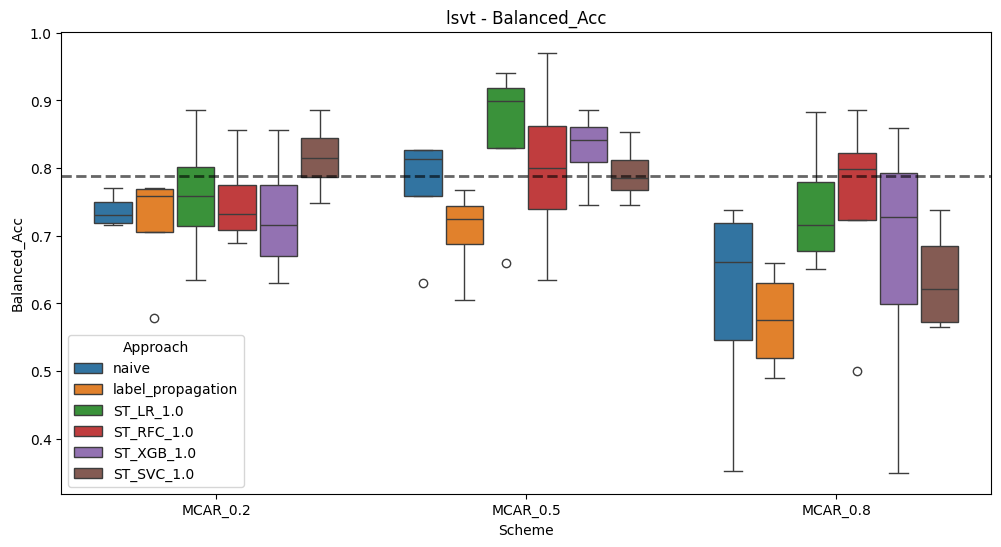

In [40]:
mcar_boxplot(results, 'Balanced_Acc', 'lsvt')

### MAR1

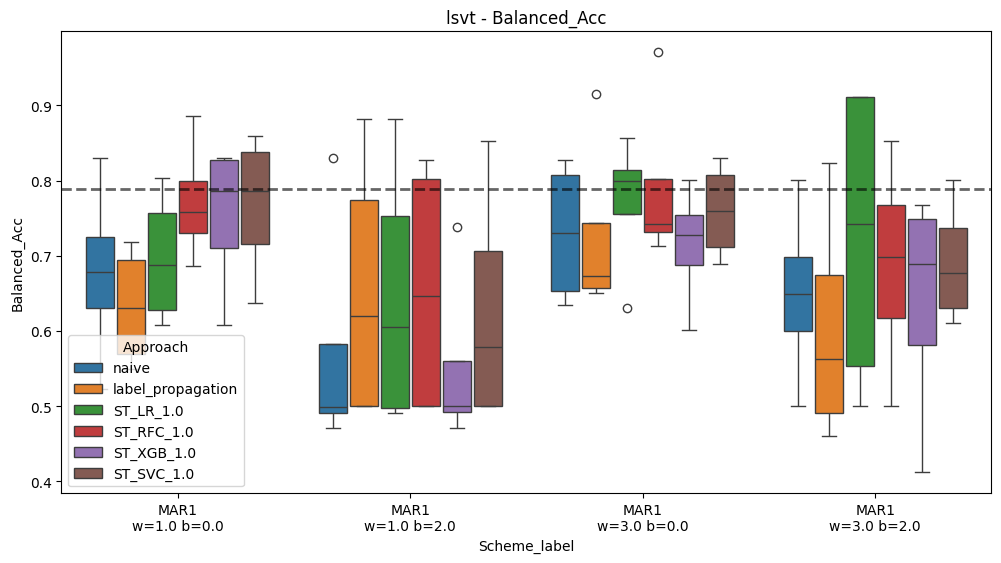

In [42]:
mar1_boxplot(df, 'Balanced_Acc', 'lsvt')

Ewentualnie liniowy że zwiększamy b od zera w górę

### MAR2

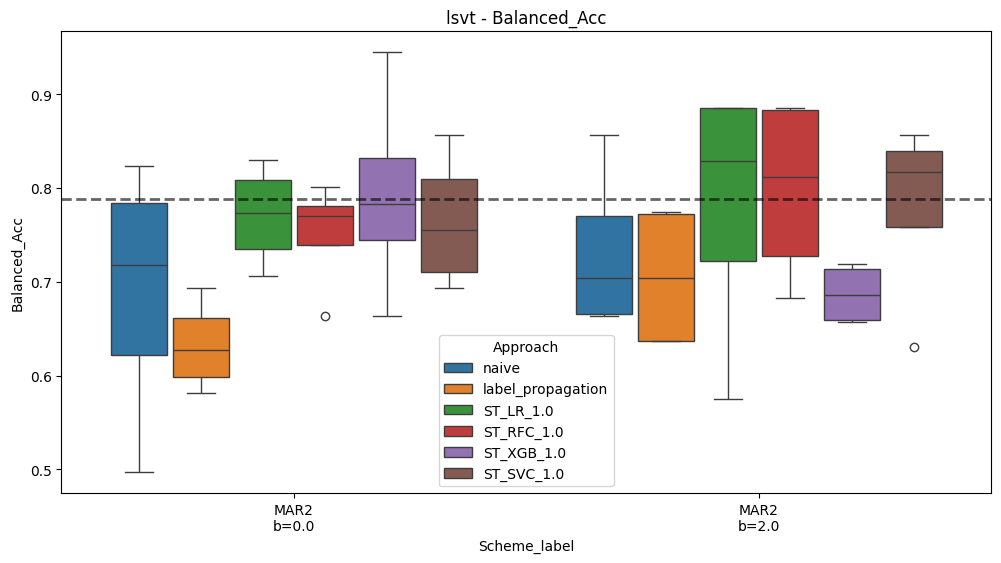

In [ ]:
mar2_boxplot(results, 'Balanced_Acc', 'lsvt')

### MNAR

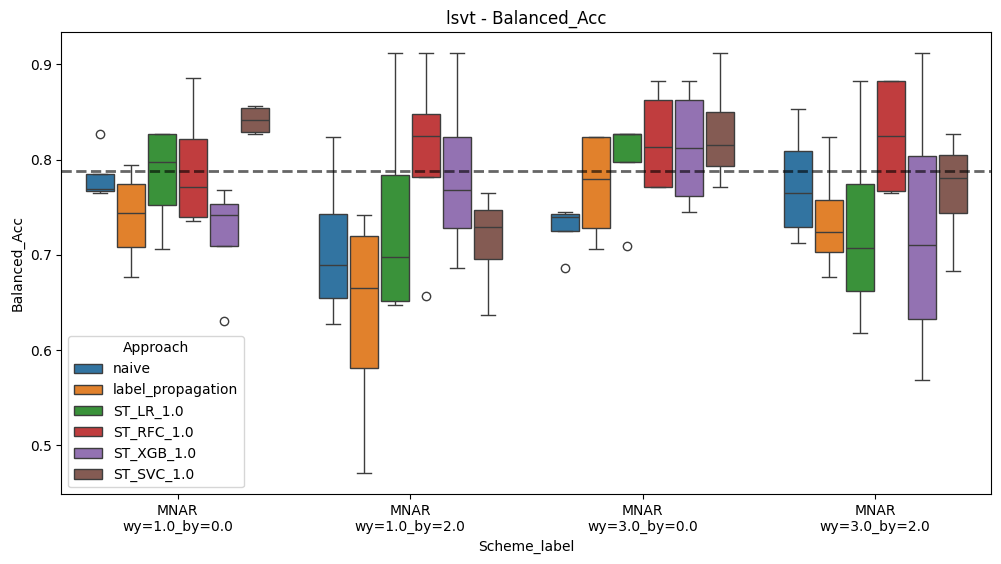

In [60]:
mnar_boxplot(results, 'Balanced_Acc', 'lsvt')